In [77]:
import numpy as np
from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem, io, plot
from ufl import TrialFunction, TestFunction, dx

from pylab import meshgrid
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyvista
import ufl
from pathlib import Path
from dolfinx.fem.petsc import LinearProblem

from dolfinx import *



In [78]:
# Create mesh and define function space
y_lim = 25.0
x_lim = 25.0

domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [128, 128])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Parameters
D_phys = fem.Constant(domain, 1.0)
theta = fem.Constant(domain, 0.5)
#Pe = fem.Constant(domain, 1e3)
t_end = 40
dt = 0.4

def velocity_field(x):
    return np.vstack((0.5 * np.ones_like(x[0]), 0.5 * np.ones_like(x[0])))

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

# Source term
def source_term(x: np.ndarray):
    values = np.zeros(x.shape[1])
    inside = np.where((x[0] < 0.22 * x_lim) & (x[0] > 0.18 * x_lim) & (x[1] < 0.42 * y_lim) & (x[1] > 0.38 * y_lim))
    values[inside] = 10.0 
    return values

f_true = fem.Function(V)
f_true.interpolate(source_term)

u0 = fem.Function(V)
u0.x.array[:] = 0.0

inlet_y_start = y_lim / 2 - 0.05 * y_lim
inlet_y_end = y_lim / 2 + 0.05 * y_lim

u_inlet = fem.Constant(domain, 1.0)

def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[0], x_lim) | \
           np.isclose(x[1], 0.0) | np.isclose(x[1], y_lim)
    

u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary), V)

U_char = ufl.sqrt(ufl.dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = ufl.CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = ufl.sqrt(ufl.inner(beta, beta))



In [79]:
tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

f = fem.Function(V, name="source")
f.x.array[:] = 0.0

v = TestFunction(V)
u = TrialFunction(V)

A1 = (1.0/Pe) * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + \
     ufl.inner(beta, ufl.grad(u)) * v * dx

A0 = (1.0/Pe) * ufl.inner(ufl.grad(u0), ufl.grad(v)) * dx + \
     ufl.inner(beta, ufl.grad(u0)) * v * dx

A = (1/dt)*(ufl.inner(u, v) - ufl.inner(u0,v)) * dx + theta* A1 + (1-theta) * A0

r = (((1/dt)*(u-u0) + theta*((1.0/Pe)* ufl.div(ufl.grad(u)) + ufl.inner(beta,ufl.grad(u))) + 
      (1-theta)*((1.0/Pe)*ufl.div(ufl.grad(u0)) + ufl.inner(beta,ufl.grad(u0)))) * 
     tau * ufl.inner(beta,ufl.grad(v))*dx)

F = A + r - f * v * dx - f * tau * ufl.dot(beta, ufl.grad(v)) * dx

L = ufl.rhs(F)
a = ufl.lhs(F)


t = 0.40 von 40.00
t = 0.80 von 40.00
t = 1.20 von 40.00
t = 1.60 von 40.00
t = 2.00 von 40.00
t = 2.40 von 40.00
t = 2.80 von 40.00
t = 3.20 von 40.00
t = 3.60 von 40.00
t = 4.00 von 40.00
t = 4.40 von 40.00
t = 4.80 von 40.00
t = 5.20 von 40.00
t = 5.60 von 40.00
t = 6.00 von 40.00
t = 6.40 von 40.00
t = 6.80 von 40.00
t = 7.20 von 40.00
t = 7.60 von 40.00
t = 8.00 von 40.00
t = 8.40 von 40.00
t = 8.80 von 40.00
t = 9.20 von 40.00
t = 9.60 von 40.00
t = 10.00 von 40.00
t = 10.40 von 40.00
t = 10.80 von 40.00
t = 11.20 von 40.00
t = 11.60 von 40.00
t = 12.00 von 40.00
t = 12.40 von 40.00
t = 12.80 von 40.00
t = 13.20 von 40.00
t = 13.60 von 40.00
t = 14.00 von 40.00
t = 14.40 von 40.00
t = 14.80 von 40.00
t = 15.20 von 40.00
t = 15.60 von 40.00
t = 16.00 von 40.00
t = 16.40 von 40.00
t = 16.80 von 40.00
t = 17.20 von 40.00
t = 17.60 von 40.00
t = 18.00 von 40.00
t = 18.40 von 40.00
t = 18.80 von 40.00
t = 19.20 von 40.00
t = 19.60 von 40.00
t = 20.00 von 40.00
t = 20.40 von 40.00
t = 

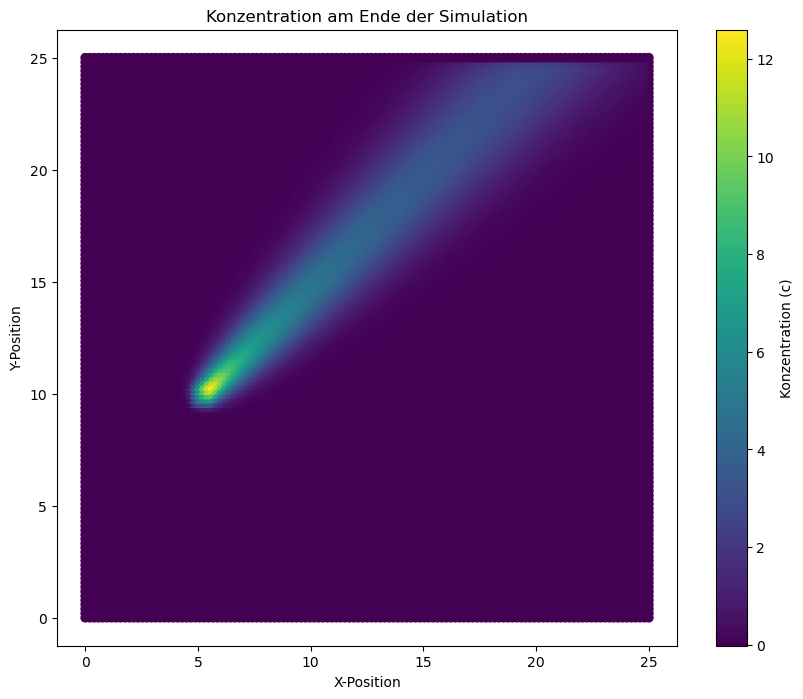

In [80]:
# Solve forward  for true source function f_true
xdmf = io.XDMFFile(domain.comm, "results_source_in_field.xdmf", "w")
xdmf.write_mesh(domain)

f.x.array[:] = f_true.x.array
lin_problem = LinearProblem(a, L, bcs=[bc_zero], 
                        petsc_options={"ksp_type": "gmres", "pc_type": "ilu"})
c = fem.Function(V)

t = 0.0
c.x.array[:] = u0.x.array

while t < t_end:
    t += dt
    print(f"t = {t:.2f} von {t_end:.2f}")

    c = lin_problem.solve()
    xdmf.write_function(c, t)
    u0.x.array[:] = c.x.array

xdmf.close()

x_coords = domain.geometry.x[:, 0]
y_coords = domain.geometry.x[:, 1]
c_values = c.x.array

plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.colorbar(label='Konzentration (c)')
plt.title('Konzentration am Ende der Simulation')
plt.xlabel('X-Position')
plt.ylabel('Y-Position')
plt.show()



Considering the previous problem as steady-state ($\frac{\partial c}{\partial t} = 0$):
$$
\beta \nabla c - D \nabla^2 c = f,
$$
we now try to solve the inverse problem and consider the PDE as discretizing FEM operator:
$$
A c = f,
$$
where $A$ is an $n \times n$ matrix. and $c, f \in \mathbb{R}^n$. The inverse problem aims to solve 
for $f$. Of course we need to consider that we do not have all concentration 
values given for this task. This is why we define a selection matrix $M \in \mathbb{R}^{p \times n}$
that aggregates $p$ values from $n$ possible grid points in $m \in \mathbb{R}^p$:
$$
M c = m.
$$
Therefore, the inverse problem aims to find a solution for
$$
(M A^{-1} f = m)
$$

In [81]:
### Inverse Problem ###
# System matrix only depends on bilinear form a(u,v) and therefore not on f
fem_matrix = fem.petsc.assemble_matrix(fem.form(a), bcs=[bc_zero])

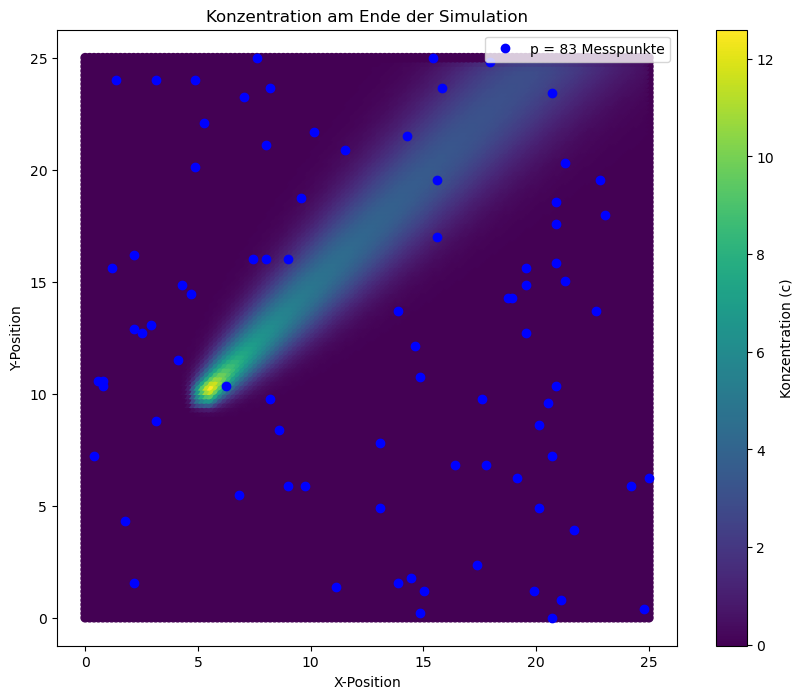

In [82]:
# Select values from c in m
n = len(c_values)
p = int(0.005 * n)
m_ids = np.random.randint(0, n+1, size=p)
m = c_values[m_ids]

plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.plot(x_coords[m_ids], y_coords[m_ids], 'bo', label=f'p = {p} Messpunkte')
plt.colorbar(label='Konzentration (c)')
plt.title('Konzentration am Ende der Simulation')
plt.xlabel('X-Position')
plt.ylabel('Y-Position')
plt.legend()
plt.show()


In [ ]:
# Inverse solution iteration

m = c_values[m_ids] 
A_matrix = fem_matrix.assemble()
A_transposed = fem_matrix.transpose().assemble()
f.x.array[:] = 0.0 # Set function f to initial guess (all zero)

max_it = 500
for i in range(1):
    # Forward problem
    c = lin_problem.solve()
    # A⊤λ(k)=−(Mc(k)−m)
    

